In [1]:
pip install tensorflow

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
(X_train,y_train),(X_test,y_test)=keras.datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 861s 5us/step


In [5]:
len(X_train)

50000

In [6]:
len(X_test)

10000

In [7]:
X_train.shape

(50000, 32, 32, 3)

In [8]:
X_train[0].shape

(32, 32, 3)

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
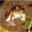

In [9]:
X_train[0]

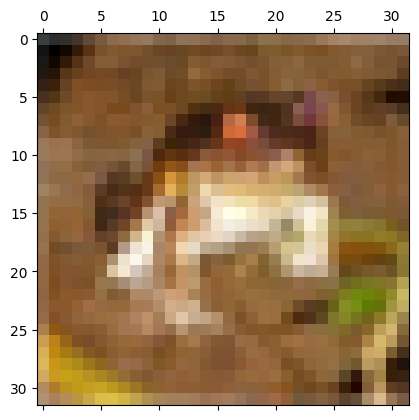

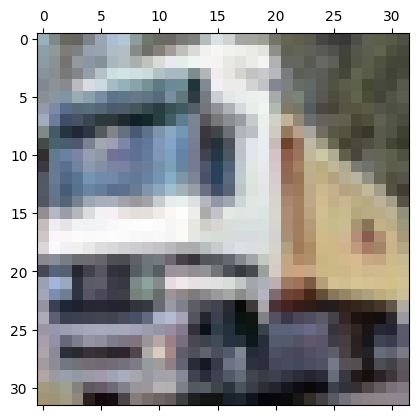

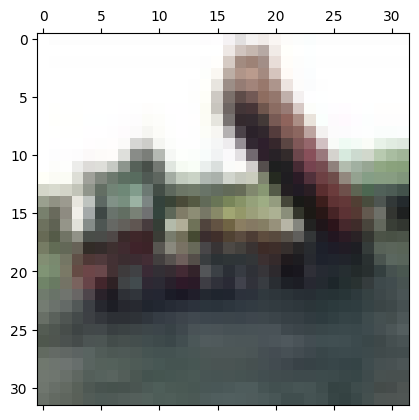

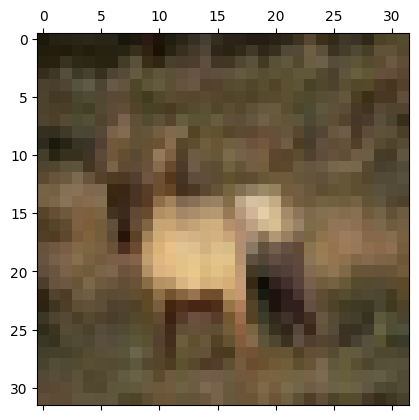

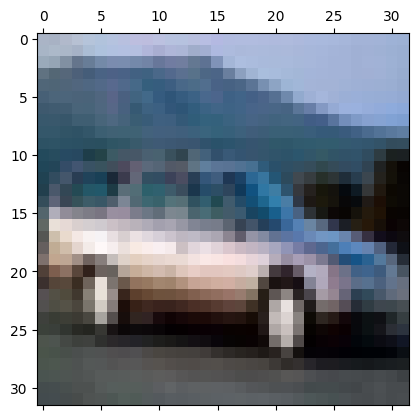

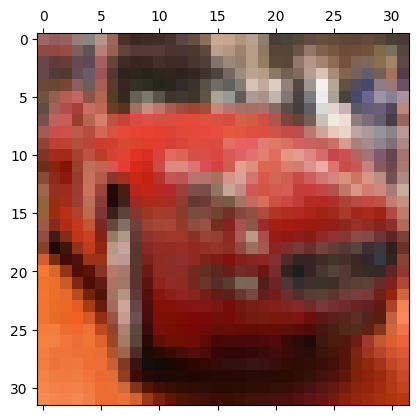

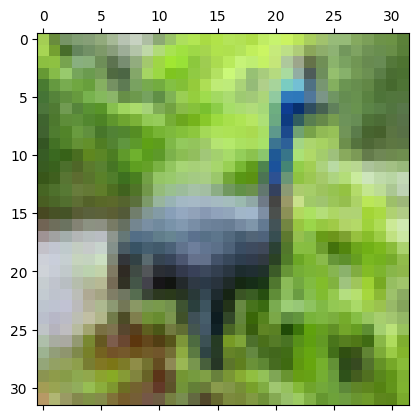

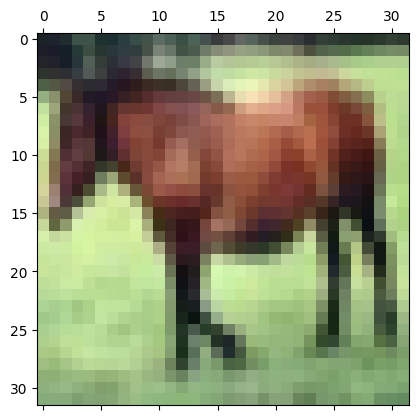

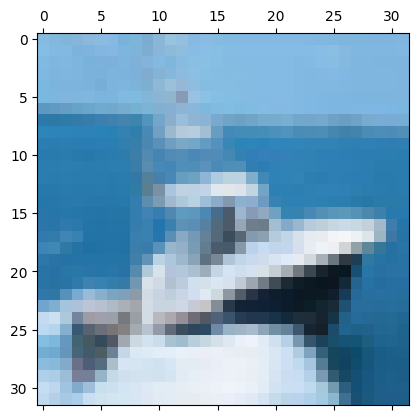

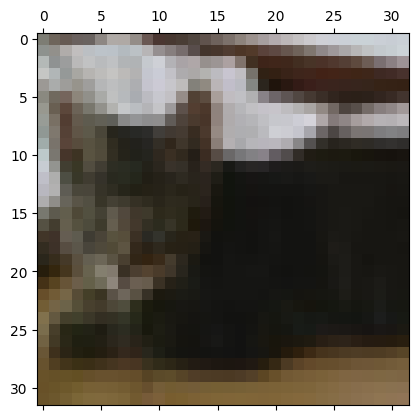

In [10]:
for i in range(10):
    plt.matshow(X_train[i])

In [11]:
for i in range(10):
    print(y_train[i])

[6]
[9]
[9]
[4]
[1]
[1]
[2]
[7]
[8]
[3]


In [12]:
X_train = X_train /  255
X_test = X_test / 255

In [13]:
X_train[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [14]:
X_train.shape

(50000, 32, 32, 3)

In [15]:
X_train.ndim

4

In [19]:
X_train_flattened = X_train.reshape(len(X_train), 32 * 32 * 3)
X_test_flattened = X_test.reshape(len(X_test), 32 * 32 * 3)

In [20]:
X_train_flattened.shape

(50000, 3072)

In [21]:
X_train_flattened[0]

array([0.23137255, 0.24313725, 0.24705882, ..., 0.48235294, 0.36078431,
       0.28235294])

In [24]:
model = keras.Sequential([
    keras.layers.Input(shape=(3072,)),
    keras.layers.Dense(10, activation='sigmoid')
])
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])
model.fit(X_train_flattened, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3194 - loss: 1.9632
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3521 - loss: 1.8824
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3608 - loss: 1.8543
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3678 - loss: 1.8449
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3710 - loss: 1.8402


In [25]:
model.evaluate(X_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3585 - loss: 1.9157


[1.9157195091247559, 0.35850000381469727]

In [26]:
y_predicted = model.predict(X_test_flattened)
y_predicted[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([0.50394   , 0.7165064 , 0.65859747, 0.9628611 , 0.28830615,
       0.5618558 , 0.8063467 , 0.08753952, 0.94088906, 0.01484378],
      dtype=float32)

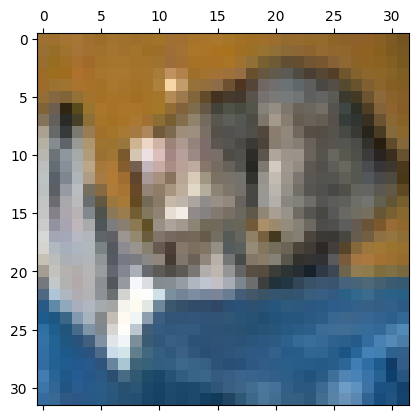

In [27]:
plt.matshow(X_test[0])

In [28]:
y_predicted[0].max()

np.float32(0.9628611)

In [29]:
np.argmax(y_predicted[0])

np.int64(3)

In [30]:
y_predicted_labels = [np.argmax(i) for i in y_predicted]

In [31]:
y_predicted_labels[:10]

[np.int64(3),
 np.int64(1),
 np.int64(8),
 np.int64(8),
 np.int64(4),
 np.int64(3),
 np.int64(3),
 np.int64(6),
 np.int64(3),
 np.int64(1)]

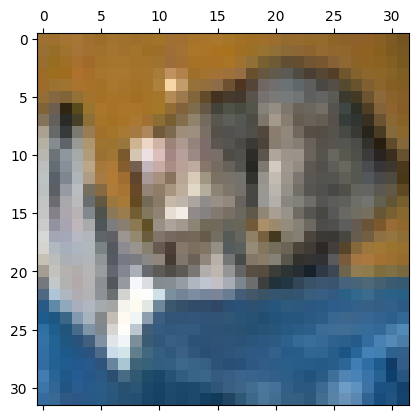

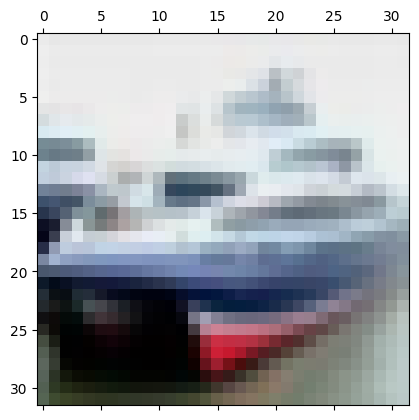

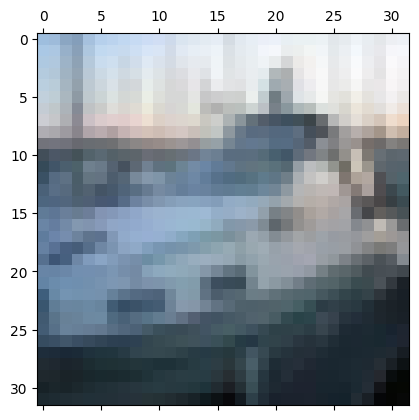

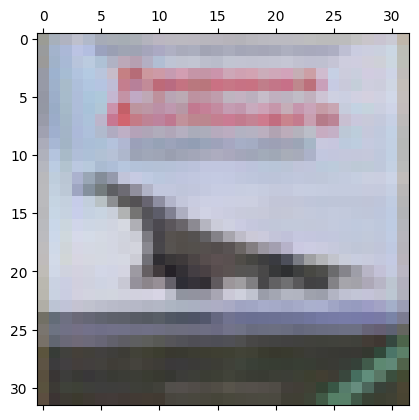

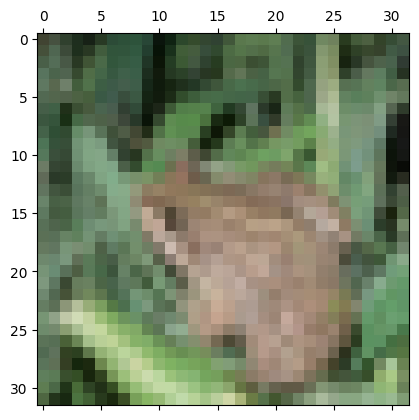

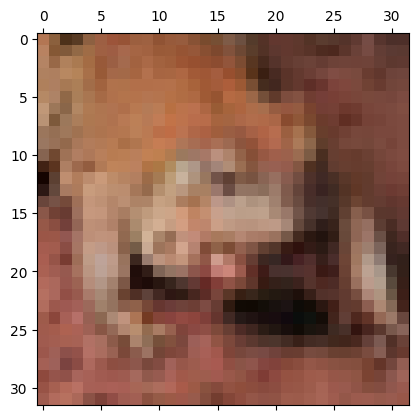

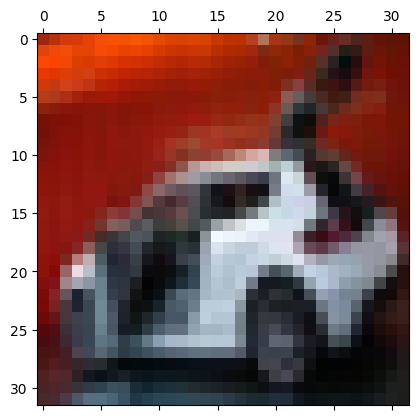

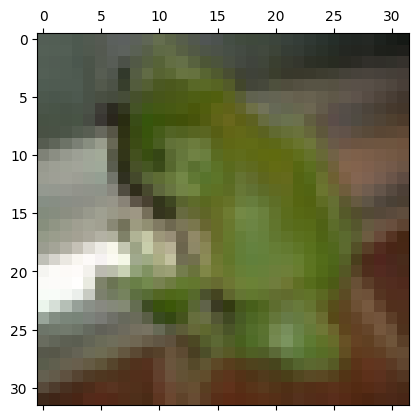

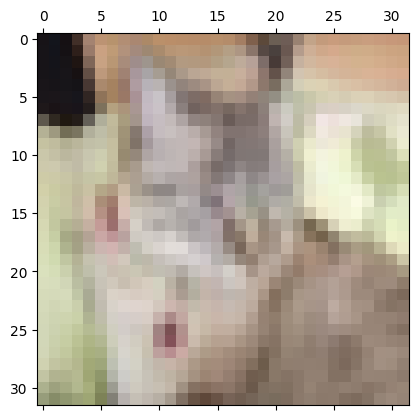

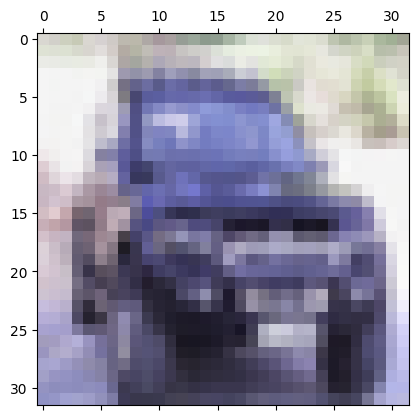

In [32]:
for i in range(10):
    plt.matshow(X_test[i])

In [33]:
cm = tf.math.confusion_matrix(labels= y_test,predictions=y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[467,  67,  25,  73,   4,   1,   8,  78, 274,   3],
       [ 62, 612,  17,  78,   8,   0,  10,  69, 131,  13],
       [121,  62, 249, 234,  52,   9,  49, 137,  86,   1],
       [ 61, 113,  63, 526,  23,  15,  22,  90,  86,   1],
       [ 72,  51, 154, 231, 190,   4,  64, 185,  49,   0],
       [ 70,  89,  86, 429,  39,  52,  13, 125,  96,   1],
       [ 20,  69,  93, 399,  52,   5, 241,  79,  40,   2],
       [ 52,  85,  49, 137,  38,   7,   9, 535,  83,   5],
       [136, 113,   6,  64,   5,   1,   3,  27, 639,   6],
       [108, 369,  11,  74,  11,   2,  19,  99, 233,  74]], dtype=int32)>

<Axes: >

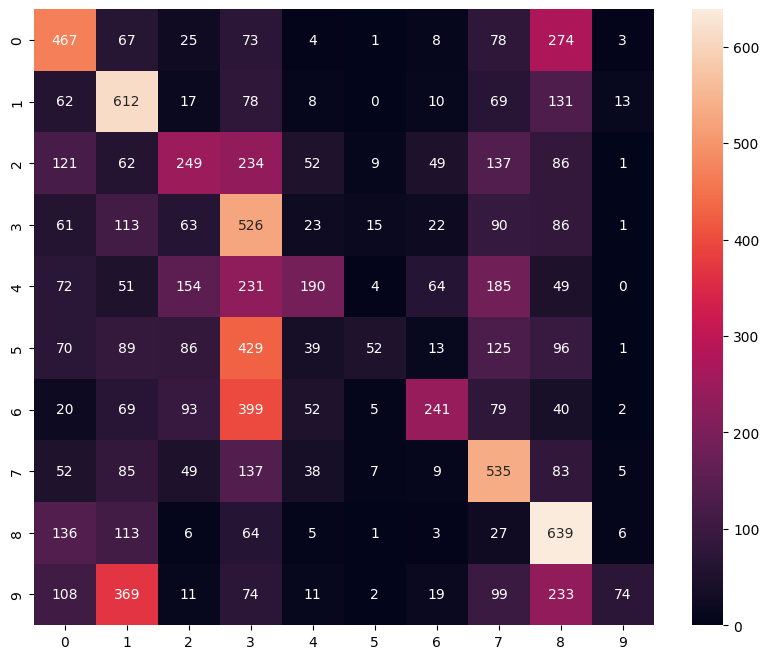

In [34]:
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True, fmt='d')

In [36]:
model = keras.Sequential([
    keras.layers.Input(shape=(3072,)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])
model.fit(X_train_flattened, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.3164 - loss: 1.9046
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3687 - loss: 1.7555
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3838 - loss: 1.7163
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3944 - loss: 1.6896
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.4040 - loss: 1.6675


In [37]:
model.evaluate(X_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4001 - loss: 1.7086


[1.708612084388733, 0.4000999927520752]

In [38]:
y_predicted = model.predict(X_test_flattened)
y_predicted_labels = [np.argmax(i) for i in y_predicted]
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)
cm

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[461,  50,  28,  18,  13,   9,  16,  25, 296,  84],
       [ 49, 569,  11,   7,  10,  12,  19,  25, 128, 170],
       [185,  47, 228,  61, 103,  52, 114,  82,  85,  43],
       [ 90,  91,  92, 172,  35, 166,  94,  64,  85, 111],
       [116,  49, 194,  39, 243,  31, 114, 112,  56,  46],
       [ 58,  63, 106,  96,  58, 278,  65, 100, 117,  59],
       [ 32,  79, 107,  93,  79,  57, 404,  30,  50,  69],
       [ 89,  60,  58,  32,  64,  43,  27, 435,  50, 142],
       [100,  86,   9,   8,   3,  11,   5,   8, 675,  95],
       [ 46, 210,   4,  12,   3,  11,  13,  31, 134, 536]], dtype=int32)>

<Axes: >

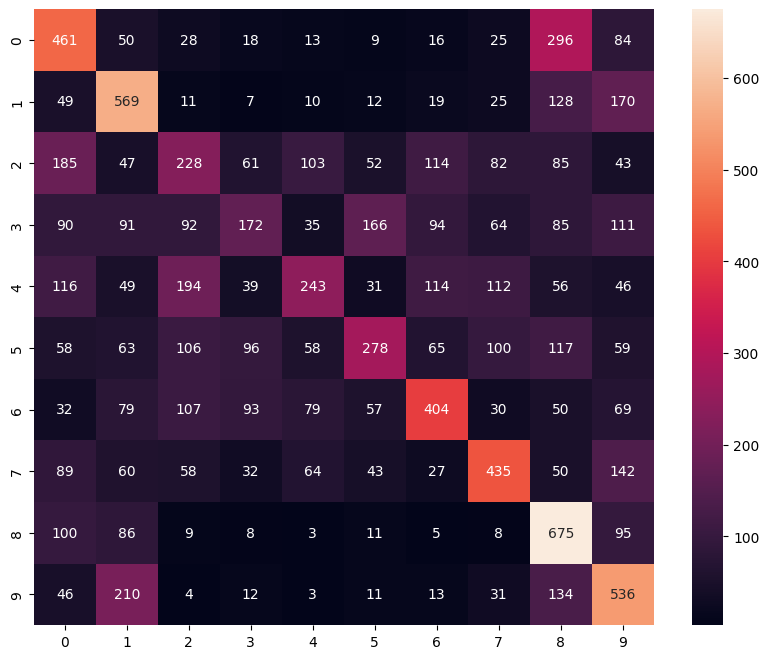

In [39]:
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='d')

In [41]:
model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Flatten(), # input layer
    keras.layers.Dense(200, activation='relu'), # Hidden Layer
    keras.layers.Dense(100, activation='relu'), # Hidden Layer
    keras.layers.Dense(10, activation='sigmoid') # output Layer
])
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.3228 - loss: 1.8684
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.3955 - loss: 1.6815
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.4258 - loss: 1.6034
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.4436 - loss: 1.5622
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.4564 - loss: 1.5244
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.4665 - loss: 1.4972
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4717 - loss: 1.4784
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4806 - loss: 1.4601
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4847 - loss: 1.4442
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.4906 - loss: 1.4335


In [42]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4619 - loss: 1.5095


[1.5095019340515137, 0.461899995803833]

In [44]:
y_predicted = model.predict(X_test)
y_predicted_labels = [np.argmax(i) for i in y_predicted]
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted_labels)
cm

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[450,  36,  50,  31,  51,  26,  16,  48, 277,  15],
       [ 38, 588,  10,  27,  14,  37,  19,  46, 142,  79],
       [ 63,  23, 282,  99, 201,  88,  89,  88,  58,   9],
       [ 23,  19,  66, 332,  79, 239,  87,  79,  52,  24],
       [ 52,  13, 115,  85, 440,  48,  94,  94,  53,   6],
       [ 14,  18,  75, 204,  90, 376,  51, 108,  50,  14],
       [  5,  16,  83, 142, 150,  63, 461,  44,  28,   8],
       [ 36,  28,  41,  56, 110,  66,  19, 578,  46,  20],
       [ 55,  47,   5,  32,  20,  31,   7,  15, 768,  20],
       [ 36, 226,   7,  52,  18,  27,  15,  68, 207, 344]], dtype=int32)>

<Axes: >

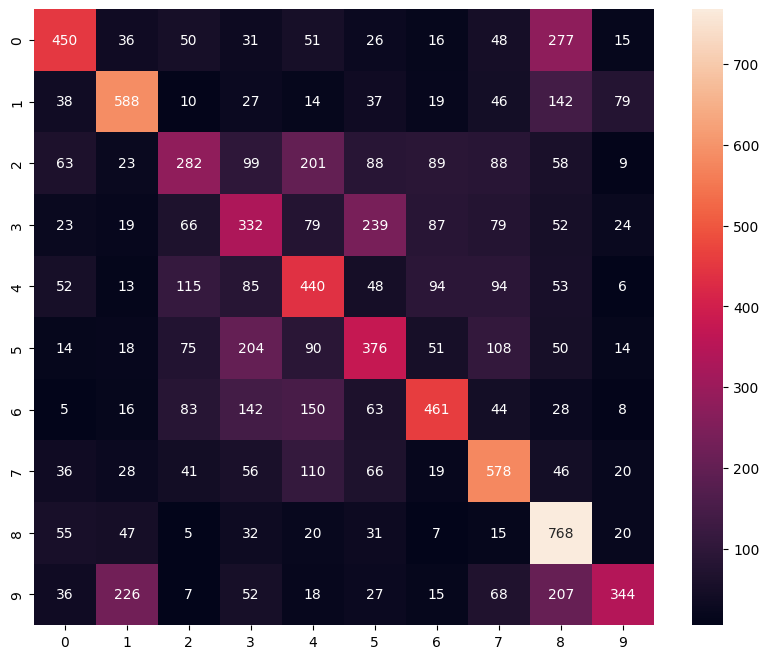

In [45]:
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='d')